# 1. Polynomial Regression için gerekli kütüphane

In [ ]:
# Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


df = pd.read_csv("trainDataSet.csv", sep=';')

print("Veri yüklendi")
print(df.head())

Veri yüklendi
   Month  DayOfWeek  FlightDate Operating_Airline  \
0      1          3  2023-01-04                AS   
1      1          7  2023-01-29                G7   
2      1          2  2023-01-10                AA   
3      1          2  2023-01-03                UA   
4      1          4  2023-01-12                AA   

   Flight_Number_Operating_Airline  OriginAirportID Origin    OriginCityName  \
0                              435            14747    SEA       Seattle, WA   
1                             4445            12264    IAD    Washington, DC   
2                             2373            14262    PSP  Palm Springs, CA   
3                             2336            12264    IAD    Washington, DC   
4                             2461            14107    PHX       Phoenix, AZ   

   DestAirportID Dest  ... Diverted  CRSElapsedTime  ActualElapsedTime  \
0          14771  SFO  ...        0             135                170   
1          14685  SAV  ...        0   

# 2. Feature ve Target seçimi

In [ ]:
X = df[['LateAircraftDelay']]
y = df['ArrDelayMinutes']

# 3. Veriyi temizleme

In [6]:
X = pd.to_numeric(X['LateAircraftDelay'], errors='coerce')
y = pd.to_numeric(y, errors='coerce')

data = pd.concat([X, y], axis=1).dropna()

X = data[['LateAircraftDelay']]
y = data['ArrDelayMinutes']

# 4. Polynomial Feature oluşturma

In [7]:
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

# 5. Model oluşturma ve eğitme

In [8]:
model = LinearRegression()

model.fit(X_poly, y)

print("Polynomial model eğitildi")

Polynomial model eğitildi


# 6. Tahmin yapma

In [9]:
y_pred = model.predict(X_poly)

# 7. Polynomial eğriyi görselleştirme

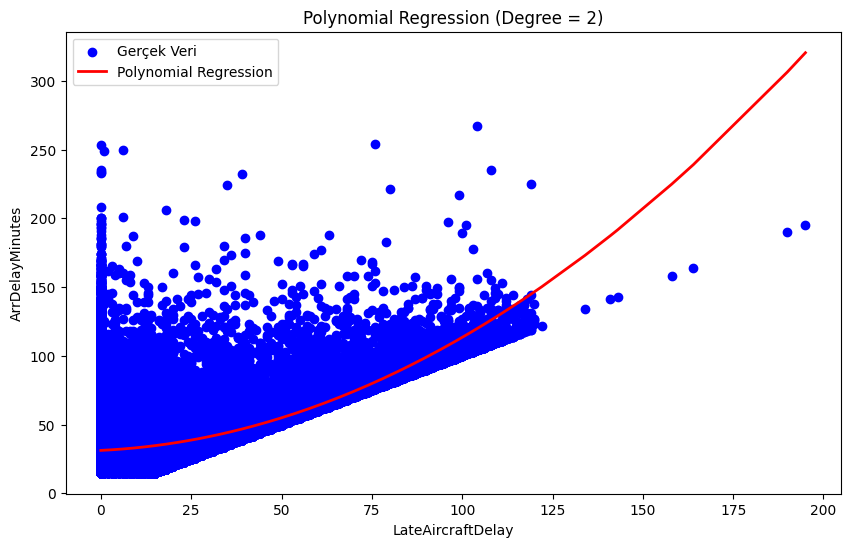

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(X, y, color='blue', label='Gerçek Veri')

# düzgün eğri çizmek için sıralama
sorted_index = X['LateAircraftDelay'].argsort()

plt.plot(X.iloc[sorted_index],
         y_pred[sorted_index],
         color='red',
         linewidth=2,
         label='Polynomial Regression')

plt.xlabel("LateAircraftDelay")
plt.ylabel("ArrDelayMinutes")

plt.title("Polynomial Regression (Degree = 2)")

plt.legend()

plt.show()